We don't have actual options price data - so we can't simulate exact P&L from selling straddles or variance swaps. Instead use daily_return = -position(t-1) × ΔVIX(t) / VIX(t-1)

In [52]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path.cwd().parent
DATA_PROCESSED = ROOT / "data" / "processed"

data = pd.read_csv(DATA_PROCESSED / "positions.csv",
                   index_col=0, parse_dates=True)
SPLIT = "2016-01-01"
data_full = data.copy()
data = data[data.index >= SPLIT]

print(f"Out-of-sample period: {data.index[0].date()} → {data.index[-1].date()}")
print(f"Rows: {len(data)}")

Out-of-sample period: 2016-01-04 → 2026-05-22
Rows: 2612


iv_daily = (VIX/100)² / 252
rv_daily = log_ret²
strat_ret = position(t-1) × (iv_daily(t-1) − rv_daily(t))

In [53]:
# P&L: collect implied variance, pay realised variance
# Lagged position — size yesterday, collect today
data["strat_ret"] = data["position"].shift(1) * (data["iv_daily"].shift(1) - data["rv_daily"])

data["spx_ret"] = np.log(data["spx"] / data["spx"].shift(1))
data = data.dropna(subset=["strat_ret", "spx_ret"])

print(f"Strategy return mean (daily): {data['strat_ret'].mean():.6f}")
print(f"Strategy return std  (daily): {data['strat_ret'].std():.6f}")
print(f"Rows in backtest: {len(data)}")

Strategy return mean (daily): 0.000015
Strategy return std  (daily): 0.000076
Rows in backtest: 2611


In [54]:
# Cumulative returns
data["strat_cum"]  = (1 + data["strat_ret"]).cumprod()
data["spx_cum"]    = (1 + data["spx_ret"]).cumprod()

# Drawdown
rolling_max        = data["strat_cum"].cummax()
data["drawdown"]   = (data["strat_cum"] - rolling_max) / rolling_max

In [55]:
def performance_metrics(returns, label):
    ann_return  = returns.mean() * 252
    ann_vol     = returns.std() * np.sqrt(252)
    sharpe      = ann_return / ann_vol
    max_dd      = ((1 + returns).cumprod() / 
                   (1 + returns).cumprod().cummax() - 1).min()
    downside    = returns[returns < 0].std() * np.sqrt(252)
    sortino     = ann_return / downside if downside > 0 else np.nan
    calmar      = ann_return / abs(max_dd) if max_dd != 0 else np.nan
    win_rate    = (returns > 0).mean()

    print(f"\n{label}")
    print(f"  Annualised return:  {ann_return*100:.2f}%")
    print(f"  Annualised vol:     {ann_vol*100:.2f}%")
    print(f"  Sharpe ratio:       {sharpe:.3f}")
    print(f"  Sortino ratio:      {sortino:.3f}")
    print(f"  Calmar ratio:       {calmar:.3f}")
    print(f"  Max drawdown:       {max_dd*100:.2f}%")
    print(f"  Win rate:           {win_rate*100:.1f}%")

performance_metrics(data["strat_ret"], "VRP Strategy")
performance_metrics(data["spx_ret"],   "SPX Buy & Hold")


VRP Strategy
  Annualised return:  0.37%
  Annualised vol:     0.12%
  Sharpe ratio:       3.054
  Sortino ratio:      1.499
  Calmar ratio:       1.735
  Max drawdown:       -0.21%
  Win rate:           76.0%

SPX Buy & Hold
  Annualised return:  12.66%
  Annualised vol:     18.03%
  Sharpe ratio:       0.702
  Sortino ratio:      0.827
  Calmar ratio:       0.351
  Max drawdown:       -36.10%
  Win rate:           54.8%


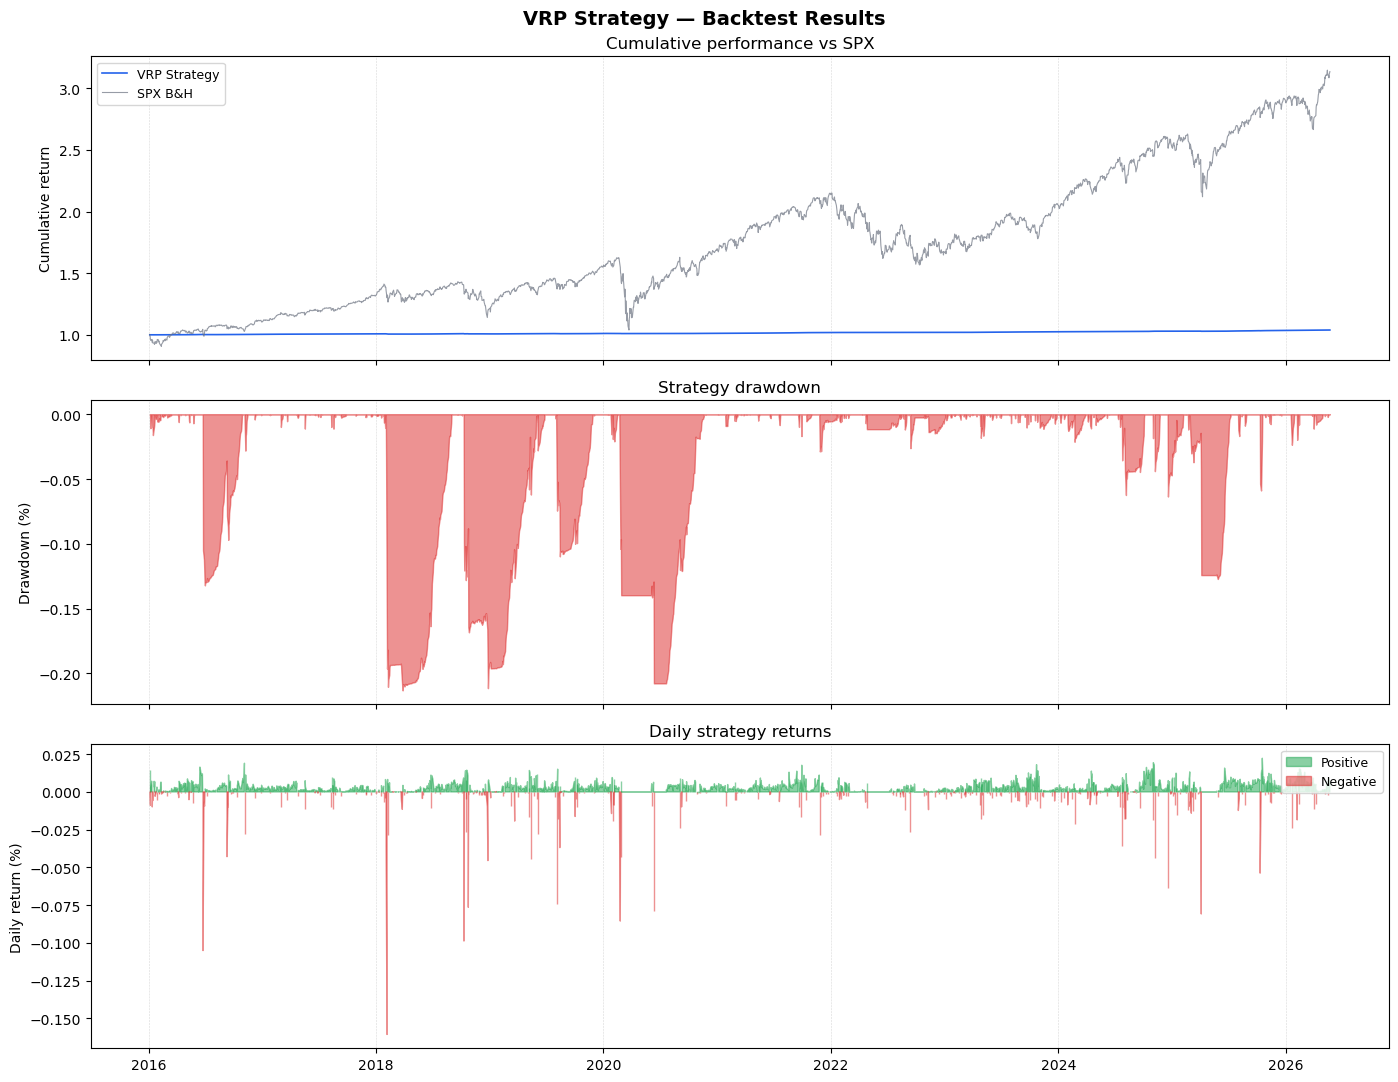

In [56]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle("VRP Strategy — Backtest Results", fontsize=14, fontweight="bold")

# Panel 1: Cumulative returns
axes[0].plot(data.index, data["strat_cum"], 
             color="#2563eb", linewidth=1.2, label="VRP Strategy")
axes[0].plot(data.index, data["spx_cum"],   
             color="#6b7280", linewidth=0.8, label="SPX B&H", alpha=0.7)
axes[0].set_ylabel("Cumulative return")
axes[0].set_title("Cumulative performance vs SPX")
axes[0].legend(loc="upper left", fontsize=9)

# Panel 2: Drawdown
axes[1].fill_between(data.index, data["drawdown"] * 100, 0,
                     color="#dc2626", alpha=0.5)
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_title("Strategy drawdown")

# Panel 3: Daily returns distribution proxy
axes[2].fill_between(data.index, data["strat_ret"] * 100, 0,
                     where=data["strat_ret"] >= 0,
                     color="#16a34a", alpha=0.5, label="Positive")
axes[2].fill_between(data.index, data["strat_ret"] * 100, 0,
                     where=data["strat_ret"] < 0,
                     color="#dc2626", alpha=0.5, label="Negative")
axes[2].set_ylabel("Daily return (%)")
axes[2].set_title("Daily strategy returns")
axes[2].legend(loc="upper right", fontsize=9)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(axis="x", linestyle="--", linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "backtest_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [57]:
# returns are in variance units, we want percentage capital return. Convert over to P&L using target volatility of 10%
TARGET_VOL   = 0.10          # annualised target volatility
VOL_WINDOW   = 126           # trailing days for vol estimate (1 quarter)
SCALAR_CAP   = 100.0         # maximum leverage multiple - prevents blowup in low-vol periods. Can tune for capital constraints
rolling_vol = (
    data["strat_ret"]
    .rolling(VOL_WINDOW)
    .std()
    .shift(1)          # <-- no look-ahead, use prev day vol to size today's position
    * np.sqrt(252)
)
rolling_scalar = (TARGET_VOL / rolling_vol).clip(upper=SCALAR_CAP)

data["rolling_scalar"] = rolling_scalar
data["strat_ret_scaled"] = data["strat_ret"] * data["rolling_scalar"]

data = data.dropna(subset=["strat_ret_scaled"])

print(f"Rolling scalar — mean:  {rolling_scalar.mean():.1f}x")
print(f"Rolling scalar — median:{rolling_scalar.median():.1f}x")
print(f"Rolling scalar — max:   {rolling_scalar.max():.1f}x  (cap={SCALAR_CAP}x)")
print(f"Rolling scalar — min:   {rolling_scalar.min():.1f}x")
print(f"Days scalar hit cap:    {(rolling_scalar >= SCALAR_CAP).sum()} "
      f"({(rolling_scalar >= SCALAR_CAP).mean()*100:.1f}%)")

performance_metrics(data["strat_ret_scaled"], "VRP Strategy (rolling vol-target 10%)")

Rolling scalar — mean:  84.1x
Rolling scalar — median:100.0x
Rolling scalar — max:   100.0x  (cap=100.0x)
Rolling scalar — min:   41.1x
Days scalar hit cap:    1352 (51.8%)

VRP Strategy (rolling vol-target 10%)
  Annualised return:  31.94%
  Annualised vol:     10.37%
  Sharpe ratio:       3.080
  Sortino ratio:      1.479
  Calmar ratio:       1.627
  Max drawdown:       -19.64%
  Win rate:           76.1%


In [9]:
print("Caveat 1: Variance swap proxy, not real options P&L")
print("Caveat 2: No transaction costs modelled here - see 08_transaction_costs.ipynb")
print("Caveat 3: Sharpe above isn't tested for significance - see 06_permutation_testing.ipynb")
print("Caveat 4: One position-sizing scheme shown - see 07_position_sizing_comparison.ipynb")

Caveat 1: Variance swap proxy, not real options P&L
Caveat 2: No transaction costs modelled here - see 08_transaction_costs.ipynb
Caveat 3: Sharpe above isn't tested for significance - see 06_permutation_testing.ipynb
Caveat 4: One position-sizing scheme shown - see 07_position_sizing_comparison.ipynb
